In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sys
sys.path.append("../")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (12, 4)
sns.set_theme(style="whitegrid")

##  Load features parquet:

In [2]:
master = pd.read_parquet("../data/processed/olist_features.parquet")
print(f"Shape: {master.shape}")

Shape: (96999, 38)


##  OTIF Rate (On Time In Full):

In [3]:
otif_rate = 1 - master["is_late"].mean()
bad_review_rate = master["is_bad_review"].mean()
avg_review_score = master["review_score"].mean()
avg_delivery_delay = master["delivery_delay_days"].mean()

print("=" * 40)
print(f"  OTIF Rate:          {otif_rate:.1%}")
print(f"  Bad Review Rate:    {bad_review_rate:.1%}")
print(f"  Avg Review Score:   {avg_review_score:.2f} / 5")
print(f"  Avg Delivery Delay: {avg_delivery_delay:.1f} days")
print("=" * 40)

  OTIF Rate:          93.2%
  Bad Review Rate:    12.8%
  Avg Review Score:   4.16 / 5
  Avg Delivery Delay: -11.9 days


## Monthly revenue trend:

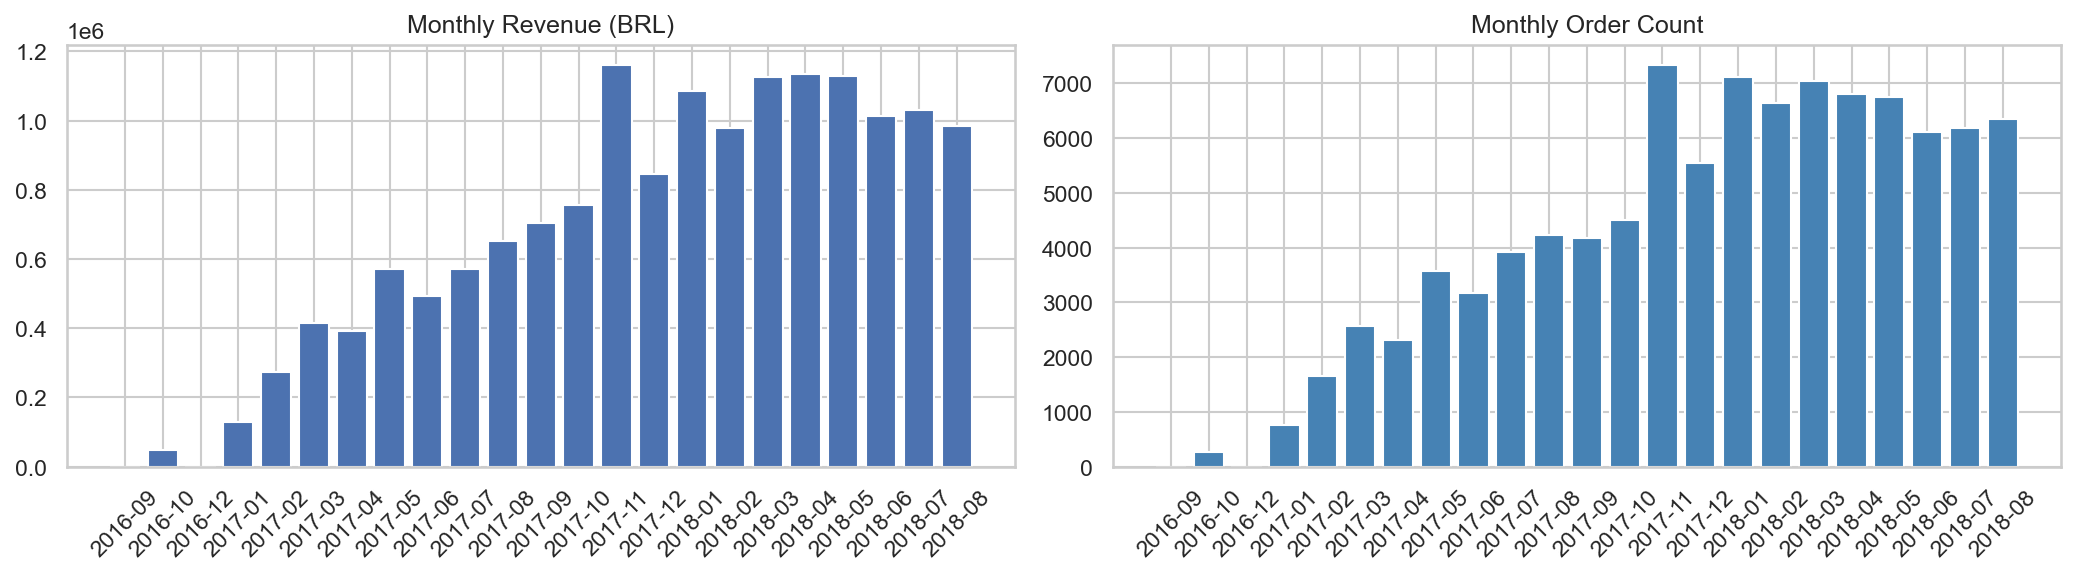

In [4]:
monthly = (
    master.groupby(master["order_purchase_timestamp"].dt.to_period("M"))
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "count")
    )
    .reset_index()
)
monthly["order_purchase_timestamp"] = monthly["order_purchase_timestamp"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly["order_purchase_timestamp"], monthly["revenue"])
axes[0].set_title("Monthly Revenue (BRL)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(monthly["order_purchase_timestamp"], monthly["orders"], color="steelblue")
axes[1].set_title("Monthly Order Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/4.0-monthly-revenue-orders.png")
plt.show()

## Late delivery rate by state:

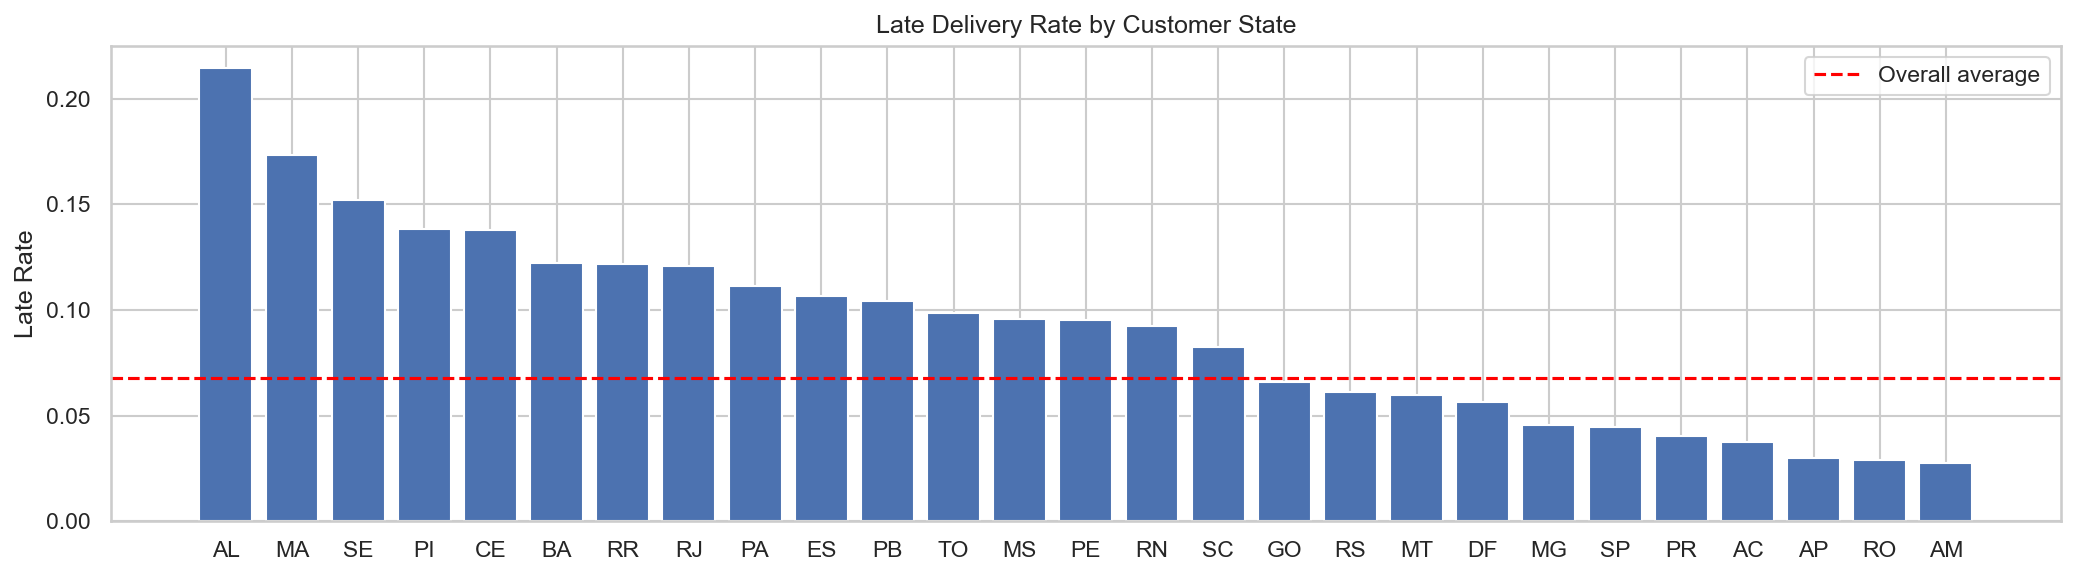

In [5]:
by_state = (
    master.groupby("customer_state")
    .agg(
        late_rate=("is_late", "mean"),
        order_count=("order_id", "count")
    )
    .sort_values("late_rate", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(by_state["customer_state"], by_state["late_rate"])
ax.set_title("Late Delivery Rate by Customer State")
ax.set_ylabel("Late Rate")
ax.axhline(master["is_late"].mean(), color="red", 
           linestyle="--", label="Overall average")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/4.0-late-rate-by-state.png")
plt.show()

##  Top and bottom 10 sellers:

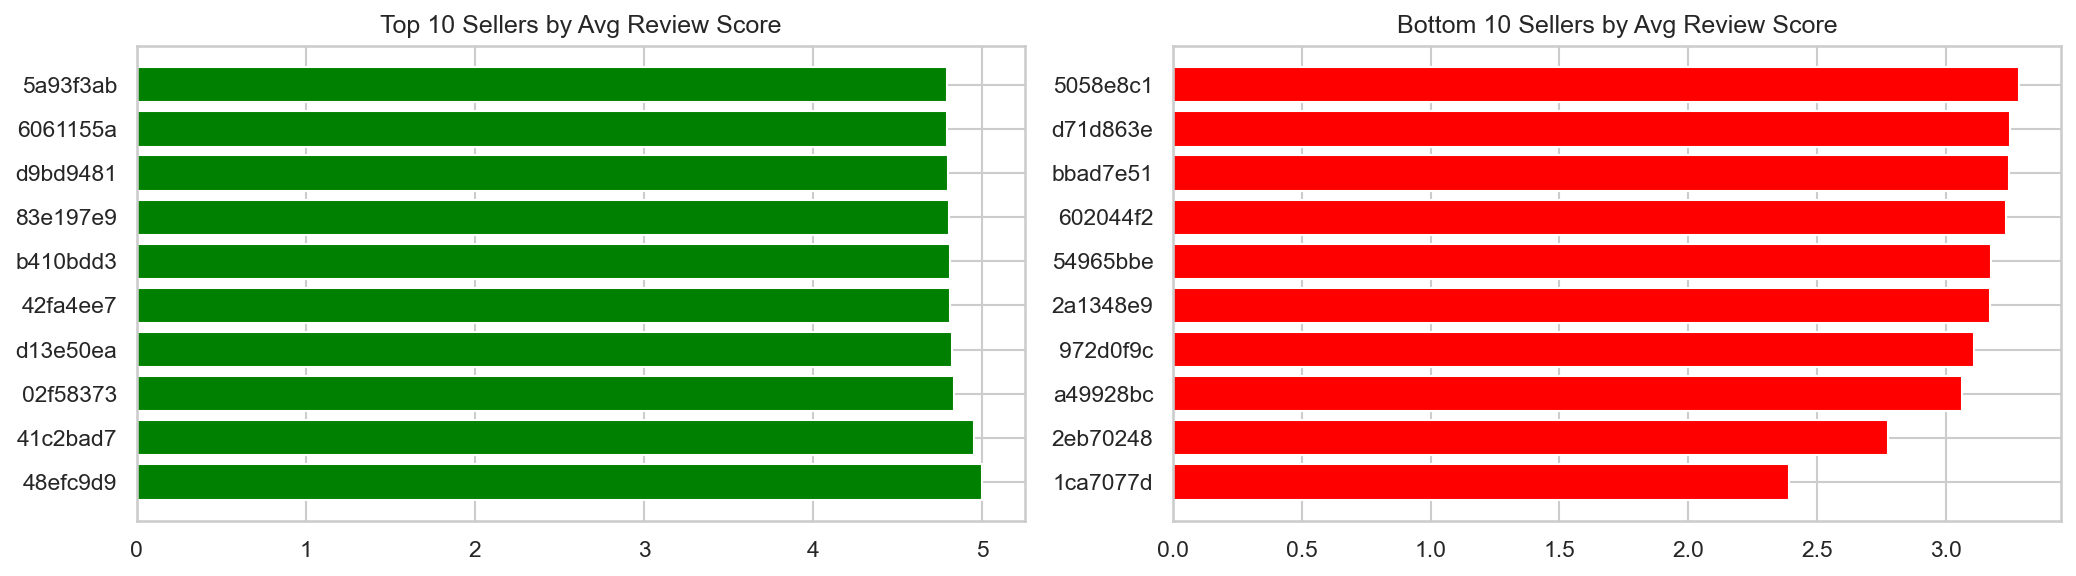

In [6]:
seller_perf = (
    master.groupby("seller_id")
    .agg(
        avg_score=("review_score", "mean"),
        late_rate=("is_late", "mean"),
        order_count=("order_id", "count"),
        revenue=("payment_value", "sum")
    )
    .query("order_count >= 20")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top10 = seller_perf.nlargest(10, "avg_score")
bot10 = seller_perf.nsmallest(10, "avg_score")

axes[0].barh(range(10), top10["avg_score"], color="green")
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([s[:8] for s in top10["seller_id"]])
axes[0].set_title("Top 10 Sellers by Avg Review Score")

axes[1].barh(range(10), bot10["avg_score"], color="red")
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([s[:8] for s in bot10["seller_id"]])
axes[1].set_title("Bottom 10 Sellers by Avg Review Score")

plt.tight_layout()
plt.savefig("../reports/figures/4.0-seller-performance.png")
plt.show()

## Review score distribution:

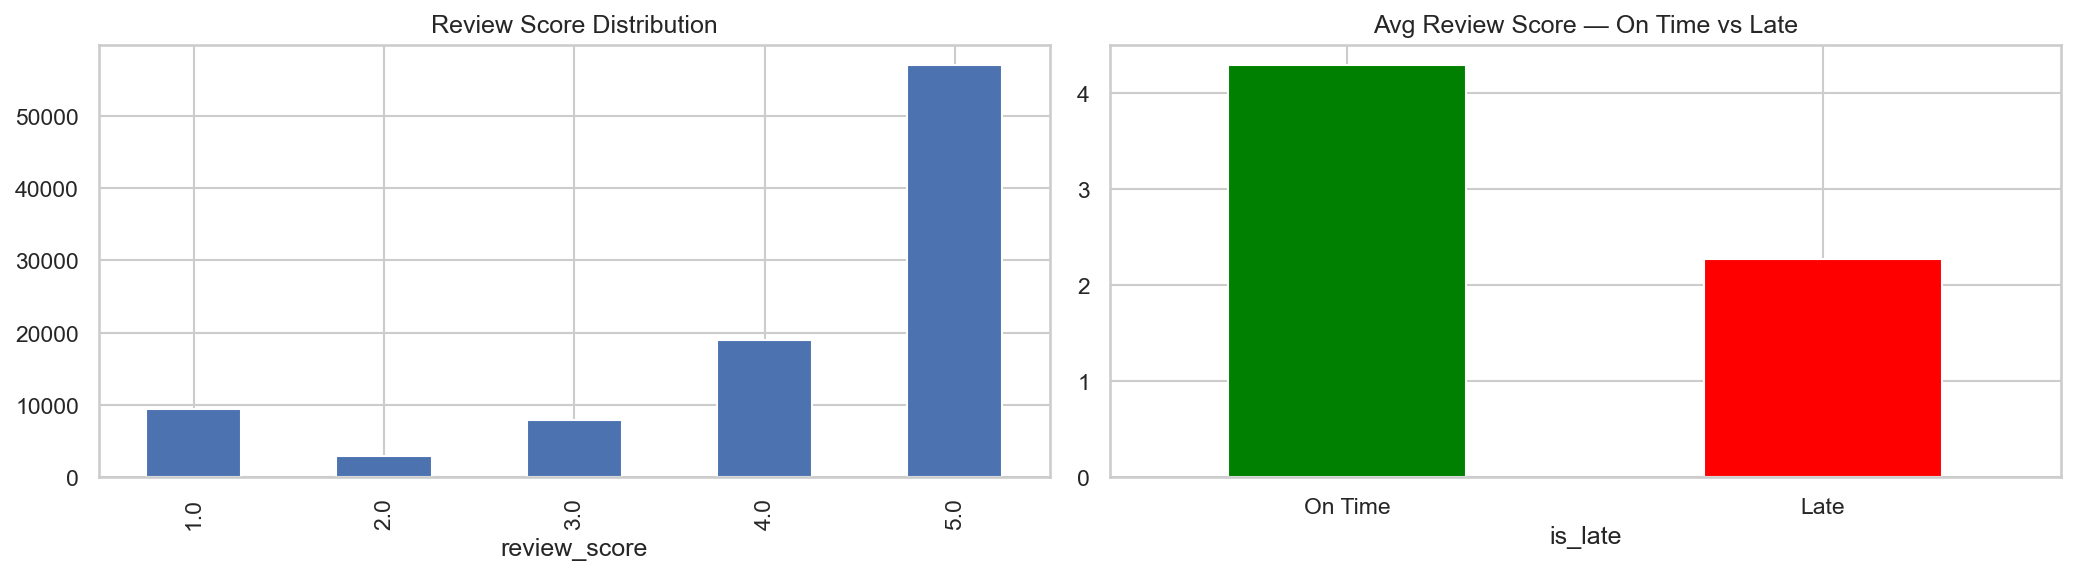

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

master["review_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Review Score Distribution"
)

master.groupby("is_late")["review_score"].mean().plot(
    kind="bar", ax=axes[1],
    title="Avg Review Score — On Time vs Late",
    color=["green", "red"]
)
axes[1].set_xticklabels(["On Time", "Late"], rotation=0)

plt.tight_layout()
plt.savefig("../reports/figures/4.0-review-scores.png")
plt.show()